# 先行研究6：べき減衰モデルの推定

In [1]:
import pymc as pm
import pytensor.tensor as pt
import arviz as az
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

print("numpy:",np.__version__)
print("pandas:",pd.__version__)
print("matplotlib:",matplotlib.__version__)
#!pip install pymc pytensor
!pip show pymc
!pip show pytensor

numpy: 2.4.2
pandas: 3.0.1
matplotlib: 3.10.8
Name: pymc
Version: 5.28.2
Summary: Probabilistic Programming in Python: Bayesian Modeling and Probabilistic Machine Learning with PyTensor
Home-page: http://github.com/pymc-devs/pymc
Author: 
Author-email: 
License: Apache License, Version 2.0
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: arviz, cachetools, cloudpickle, numpy, pandas, pytensor, rich, scipy, threadpoolctl, typing-extensions
Required-by: 
Name: pytensor
Version: 2.38.2
Summary: Optimizing compiler for evaluating mathematical expressions on CPUs and GPUs.
Home-page: https://github.com/pymc-devs/pytensor
Author: 
Author-email: pymc-devs <pymc.devs@gmail.com>
License-Expression: BSD-3-Clause
Location: C:\Users\h20s1\workspace\.venv\Lib\site-packages
Requires: cons, etuples, filelock, logical-unification, miniKanren, numba, numpy, scipy, setuptools
Required-by: pymc


In [2]:
import sys
from pathlib import Path
# projectルートを追加
sys.path.append(str(Path().resolve().parent))

In [3]:
# make dataframe
from src.data_loader import load_csv_with_datetime_index
from src.preprocessing import normalize_default_counts

df = load_csv_with_datetime_index(
    "../data/raw/M.csv",
    date_col="Year",
    date_format="%Y",
)

df = normalize_default_counts(df, scale=3000)

from src.data_loader import load_init_params
params = load_init_params()

lambda0_init = params["scalar"]["lambda0_init"]
alpha_init   = params["scalar"]["alpha_init"]
theta_init   = params["scalar"]["theta_init"]
gamma_init   = params["scalar"]["gamma_init"]

lambda0_se = params["scalar"]["lambda0_se"]
alpha_se   = params["scalar"]["alpha_se"]
theta_se   = params["scalar"]["theta_se"]
gamma_se   = params["scalar"]["gamma_se"]

y_init = pd.Series(params["y_init"], index=df.index, name="y_t")

=== CSV loaded ===
shape: (99, 7)
columns: ['Year', 'SG', 'D_SG', 'IG', 'D_IG', 'ALL', 'D_ALL']
=== DatetimeIndex set ===
<class 'pandas.DatetimeIndex'>
DatetimeIndex(['1920-01-01', '1921-01-01', '1922-01-01', '1923-01-01',
               '1924-01-01'],
              dtype='datetime64[us]', name='Year', freq=None)
[normalize_default_counts] created 'SG_norm' from 'D_SG' / 'SG' * 3000
[normalize_default_counts] created 'IG_norm' from 'D_IG' / 'IG' * 3000
[normalize_default_counts] created 'ALL_norm' from 'D_ALL' / 'ALL' * 3000


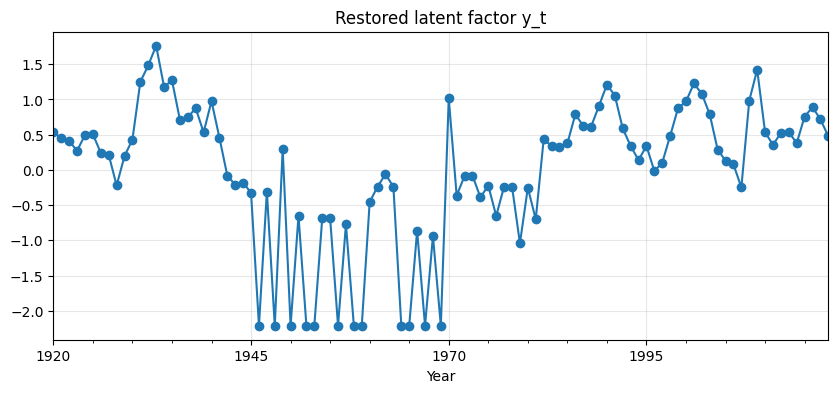

In [4]:
y_init .plot(figsize=(10, 4), marker="o")
plt.title("Restored latent factor y_t")
plt.grid(alpha=0.3)
plt.show()

## Power-law-kernel model

$$
X_t \mid \eta_0,\alpha,\mathbf y
\sim
\text{Poisson}\!\left(\exp(\eta_0+\alpha y_t)\right)
$$

$$
\mathbf y \sim \mathcal N(\mathbf 0, K^{(\mathrm{pow})})
$$

$$
K^{(\mathrm{pow})}_{ij}
=
\frac{1}{(1+|t_i-t_j|)^\gamma}
$$

$$
\eta_0 \sim \mathcal N(\eta_0^{init}, c\sigma_{\eta_0}^2)
$$

$$
\alpha \sim \mathcal N^+(\alpha^{init}, c\sigma_{\alpha}^2)
$$

$$
\log \gamma \sim \mathcal N(\log \gamma^{init}, c\sigma_{\gamma}^2)
$$

In [11]:
from src.models_poisson_power import sample_power_kernel_model

trace_pow = sample_power_kernel_model(
    data=df["ALL_norm"],
    lambda0_init=lambda0_init,
    alpha_init=alpha_init,
    gamma_init=gamma_init,
    lambda0_se=lambda0_se,
    alpha_se=alpha_se,
    gamma_se=gamma_se,
    y_init=y_init,
    prior_scale=1.0,
    draws=2000,
    tune=2000,
    chains=4,
    target_accept=0.95,
)


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [eta0, alpha, log_gamma, y]


C:\Users\h20s1\workspace\.venv\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for Jupyter 
support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 127 seconds.


In [12]:
import arviz as az
az.summary(trace_pow, var_names=["lambda0" , "alpha", "gamma"])

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
lambda0,15.378,0.475,14.488,16.261,0.010,0.005,2175.0,4309.0,1.0
alpha,1.592,0.031,1.533,1.647,0.001,0.000,2512.0,3863.0,1.0
gamma,0.523,0.038,0.454,0.596,0.000,0.000,10057.0,6175.0,1.0


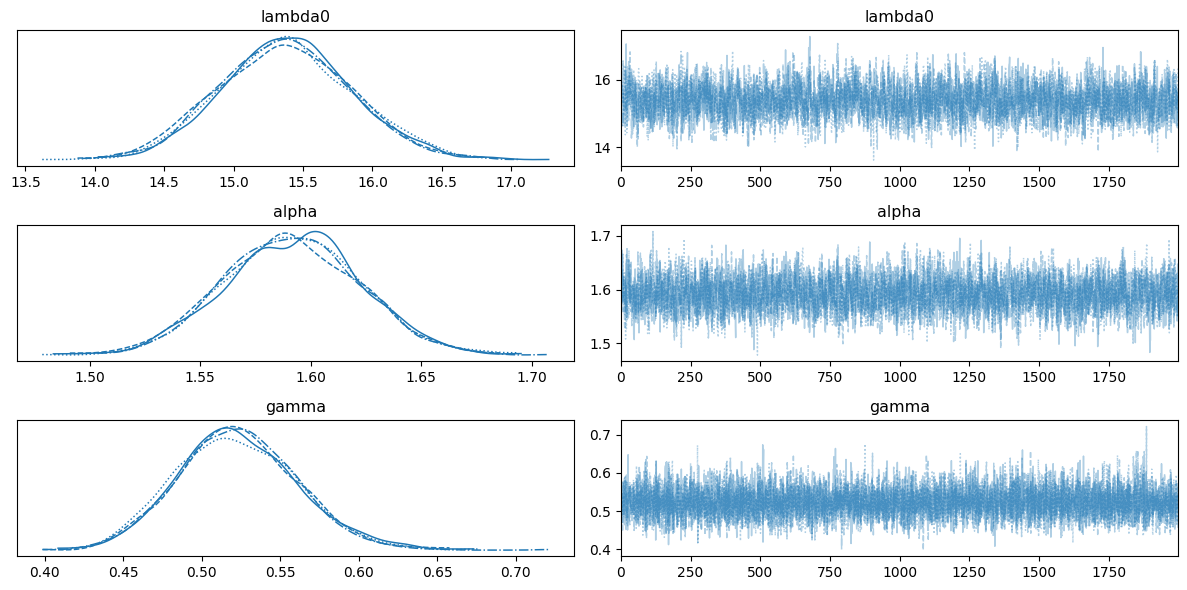

In [13]:
az.plot_trace(trace_pow, var_names=["lambda0", "alpha", "gamma"])
plt.tight_layout()
plt.show()